--- COMPREHENSIVE ABLATION BIAS ANALYSIS ---
Analyzing A5 (Priors)...
Analyzing A4 (Seq Only)...


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:515: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


Analyzing A1 (Seq+Priors)...
Analyzing A2 (GAT+Priors)...
Analyzing A3 (Concat All)...

BIAS ANALYSIS RESULTS:
             Model  TATA Correlation  CpG Correlation
0      A5 (Priors)          0.316209         0.041162
1    A4 (Seq Only)         -0.018503         0.135923
2  A1 (Seq+Priors)          0.253255         0.063363
3  A2 (GAT+Priors)          0.293113         0.112607
4  A3 (Concat All)          0.361198        -0.027777


/tmp/ipython-input-3840066575.py:222: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='TATA Correlation', y='Model', data=df_bias, palette='viridis')


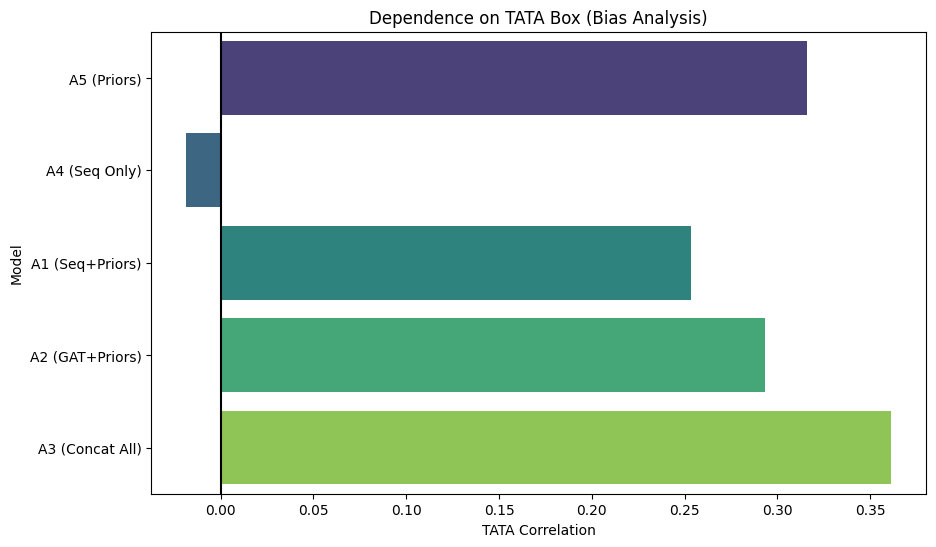

✅ Full Ablation Analysis Saved to /content/drive/MyDrive/BWAF-Net-Training/results_xai_ablation/


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from scipy.stats import spearmanr
import os

# --- CONFIG ---
DATASET_FILE = "/content/drive/MyDrive/BWAF-Net-Training/Final_Aligned_Dataset.csv"
GRAPH_FILE = "/content/drive/MyDrive/BWAF-Net-Training/graph_data.pt"
ABLATION_DIR = "/content/drive/MyDrive/BWAF-Net-Training/results_ablation_final2/"
OUTPUT_DIR = "/content/drive/MyDrive/BWAF-Net-Training/results_xai_ablation/"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- DATASET ---
class AblationDataset(Dataset):
    def __init__(self, df, gene_to_idx):
        self.seqs = df['sequence'].values; self.labels = df['label'].values
        self.gene_idxs = [gene_to_idx.get(g, 0) for g in df['gene_id'].values]
        self.prior_cols = ["TATA_Box", "CAAT_Box", "GC_Box", "BRE", "MRE", "PPE", "Octamer", "Sp1", "E_Box", "RFX", "CpG_Count"]
        self.priors = np.log1p(df[self.prior_cols].values.astype(np.float32))
        self.dna_map = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
    def __len__(self): return len(self.seqs)
    def __getitem__(self, i):
        seq = [self.dna_map.get(s, 4) for s in self.seqs[i]]
        return (torch.tensor(seq, dtype=torch.long), torch.tensor(self.priors[i], dtype=torch.float32),
                torch.tensor(self.gene_idxs[i], dtype=torch.long), torch.tensor(self.labels[i], dtype=torch.float32))

# --- MODEL DEFINITIONS (Fixed Dimensions) ---

class Model_A5(nn.Module):
    def __init__(self, prior_dim=11):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(prior_dim, 64), nn.ReLU(), nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, seq, priors, gidx): return self.net(priors)

class Model_A4(nn.Module):
    def __init__(self, d_model=64):
        super().__init__()
        self.emb = nn.Embedding(5, d_model, padding_idx=4)
        self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2)
        self.clf = nn.Sequential(nn.Linear(d_model, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, seq, priors, gidx):
        mask = (seq == 4) # True where padding
        x = self.emb(seq) + self.pos
        x = self.trans(x, src_key_padding_mask=mask)

        # Safe Global Pooling
        # Invert mask (True where valid data)
        valid_mask = (~mask).unsqueeze(-1).float() # [B, L, 1]
        sum_x = (x * valid_mask).sum(dim=1)        # [B, D]
        count = valid_mask.sum(dim=1).clamp(min=1) # [B, 1]
        x = sum_x / count                          # [B, D]

        return self.clf(x)

class Model_A1(nn.Module):
    def __init__(self, d_model=64, prior_dim=11):
        super().__init__()
        self.emb = nn.Embedding(5, d_model, padding_idx=4); self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2)
        self.seq_proj = nn.Linear(d_model, 64)
        self.clf = nn.Sequential(nn.Linear(64 + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, seq, priors, gidx):
        mask = (seq == 4)
        x = self.emb(seq) + self.pos
        x = self.trans(x, src_key_padding_mask=mask)

        # Safe Pooling
        valid_mask = (~mask).unsqueeze(-1).float()
        sum_x = (x * valid_mask).sum(dim=1)
        count = valid_mask.sum(dim=1).clamp(min=1)
        x = sum_x / count

        h_seq = self.seq_proj(x)
        return self.clf(torch.cat([h_seq, priors], dim=1))

class Model_A2(nn.Module):
    def __init__(self, num_nodes, num_feats, d_model=64, prior_dim=11):
        super().__init__()
        self.gat = GATConv(num_feats, d_model, heads=1)
        self.register_buffer('edge_index', None); self.register_buffer('x', None)
        self.clf = nn.Sequential(nn.Linear(d_model + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def set_graph_data(self, x, edge_index): self.x = x; self.edge_index = edge_index
    def forward(self, seq, priors, gidx):
        # Ensure Graph Data is on same device
        if self.x.device != priors.device:
            self.x = self.x.to(priors.device)
            self.edge_index = self.edge_index.to(priors.device)

        all_nodes = F.elu(self.gat(self.x, self.edge_index))
        return self.clf(torch.cat([all_nodes[gidx], priors], dim=1))

class Model_A3(nn.Module):
    def __init__(self, num_nodes, num_feats, d_model=64, prior_dim=11):
        super().__init__()
        self.emb = nn.Embedding(5, d_model, padding_idx=4); self.pos = nn.Parameter(torch.randn(1, 2000, d_model))
        self.trans = nn.TransformerEncoder(nn.TransformerEncoderLayer(d_model, 4, batch_first=True), 2)
        self.seq_proj = nn.Linear(d_model, 64)
        self.gat = GATConv(num_feats, d_model, heads=1)
        self.register_buffer('edge_index', None); self.register_buffer('x', None)
        self.clf = nn.Sequential(nn.Linear(64 + 64 + prior_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def set_graph_data(self, x, edge_index): self.x = x; self.edge_index = edge_index
    def forward(self, seq, priors, gidx):
        mask = (seq == 4)
        x = self.emb(seq) + self.pos
        x = self.trans(x, src_key_padding_mask=mask)

        valid_mask = (~mask).unsqueeze(-1).float()
        sum_x = (x * valid_mask).sum(dim=1)
        count = valid_mask.sum(dim=1).clamp(min=1)
        x = sum_x / count
        h_seq = self.seq_proj(x)

        # Graph
        if self.x.device != priors.device:
            self.x = self.x.to(priors.device)
            self.edge_index = self.edge_index.to(priors.device)
        h_graph = F.elu(self.gat(self.x, self.edge_index))[gidx]

        return self.clf(torch.cat([h_seq, h_graph, priors], dim=1))

# --- ANALYSIS ---
def analyze_all_models():
    print("--- COMPREHENSIVE ABLATION BIAS ANALYSIS ---")

    # 1. Load Data
    df = pd.read_csv(DATASET_FILE)
    test_df = df[df['partition'] == 'test']
    graph = torch.load(GRAPH_FILE, map_location=DEVICE)
    ds = AblationDataset(test_df, graph['gene_to_idx'])
    loader = DataLoader(ds, batch_size=32, shuffle=False)

    num_genes = graph['x'].shape[0]; num_feats = graph['x'].shape[1]

    # 2. Setup All Models
    models_to_test = {
        "A5 (Priors)": Model_A5(),
        "A4 (Seq Only)": Model_A4(),
        "A1 (Seq+Priors)": Model_A1(),
        "A2 (GAT+Priors)": Model_A2(num_genes, num_feats),
        "A3 (Concat All)": Model_A3(num_genes, num_feats)
    }

    # Also grab raw TATA and CpG counts for correlation
    tata_idx = ds.prior_cols.index("TATA_Box")
    cpg_idx = ds.prior_cols.index("CpG_Count")

    all_priors = []
    # Collect priors once
    for _, prior, _, _ in loader: all_priors.append(prior.numpy())
    all_priors = np.concatenate(all_priors)
    tata_values = all_priors[:, tata_idx]
    cpg_values = all_priors[:, cpg_idx]

    bias_results = []

    # 3. Loop Models
    for name, model in models_to_test.items():
        # Load Weights
        fname = name.split(" ")[0] # e.g. "A5"
        found = False
        # Search specifically for the file in the dir
        for f in os.listdir(ABLATION_DIR):
            if f.startswith(f"best_{fname}"):
                path = os.path.join(ABLATION_DIR, f)
                found = True
                break

        if not found:
            print(f"Skipping {name}: Checkpoint not found in {ABLATION_DIR}.")
            continue

        print(f"Analyzing {name}...")
        model = model.to(DEVICE)
        if hasattr(model, 'set_graph_data'): model.set_graph_data(graph['x'].to(DEVICE), graph['edge_index'].to(DEVICE))

        try:
            # Use strict=False just in case of minor buffer mismatches
            model.load_state_dict(torch.load(path, map_location=DEVICE), strict=False)
        except Exception as e:
            print(f"Error loading {name}: {e}")
            continue

        model.eval()
        probs = []
        with torch.no_grad():
            for seq, prior, gidx, y in loader:
                seq, prior, gidx = seq.to(DEVICE), prior.to(DEVICE), gidx.to(DEVICE)
                out = model(seq, prior, gidx).squeeze()
                probs.extend(torch.sigmoid(out).cpu().numpy())

        probs = np.array(probs)

        # Correlate
        r_tata, _ = spearmanr(probs, tata_values)
        r_cpg, _ = spearmanr(probs, cpg_values)

        bias_results.append({
            "Model": name,
            "TATA Correlation": r_tata,
            "CpG Correlation": r_cpg
        })

    # 4. Visualization
    if bias_results:
        df_bias = pd.DataFrame(bias_results)
        print("\nBIAS ANALYSIS RESULTS:")
        print(df_bias)
        df_bias.to_csv(os.path.join(OUTPUT_DIR, "all_ablation_bias.csv"), index=False)

        # Plot TATA Bias
        plt.figure(figsize=(10, 6))
        sns.barplot(x='TATA Correlation', y='Model', data=df_bias, palette='viridis')
        plt.title("Dependence on TATA Box (Bias Analysis)")
        plt.axvline(0, color='black')
        plt.savefig(os.path.join(OUTPUT_DIR, "all_models_tata_bias.png"))
        plt.show()

        print(f"✅ Full Ablation Analysis Saved to {OUTPUT_DIR}")
    else:
        print("No models were analyzed.")

if __name__ == "__main__":
    analyze_all_models()